# Training gc correction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from sklearn.preprocessing import scale
from statsmodels.nonparametric.smoothers_lowess import lowess

In [8]:
# generate random data
np.random.seed(1)
gc = np.random.uniform(0.2, 0.8, 1000)

true_coverage = norm.pdf(gc, loc=0.45, scale=0.15)
true_coverage = true_coverage / true_coverage.max()
noise = np.random.normal(0, 0.09, 1000)
observed_coverage = true_coverage + noise

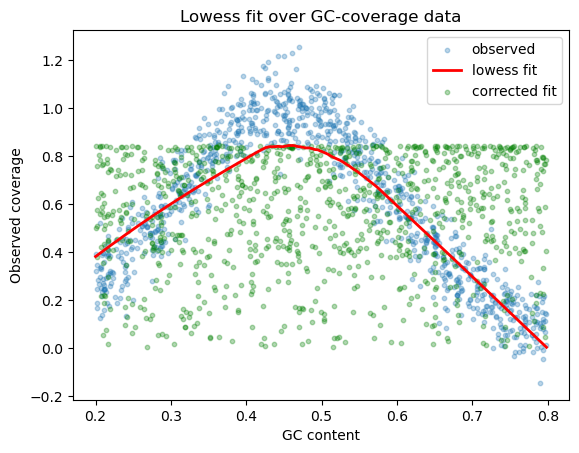

In [ ]:
smoothed = lowess(observed_coverage, gc, frac=0.75)

plt.scatter(gc, observed_coverage, alpha=0.3, s=10, label="observed")
plt.plot(smoothed[:, 0], smoothed[:, 1], color="red", linewidth=2, label="lowess fit")
plt.xlabel("GC content")
plt.ylabel("Observed coverage")
plt.title("Lowess fit over GC-coverage data")
plt.legend()
plt.show()

In [ ]:
global_mean = np.mean(observed_coverage)
# interpolate to the original gc values

corrected_coverage = np.interp(gc, smoothed[:, 0], smoothed[:, 1])

corrected_final = observed_coverage * global_mean / corrected_coverage

In [ ]:
gc_content_per_region = pd.read_csv("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/processing/gc_content_per_region.csv", index_col=0)


In [ ]:
coverage_subsample = pd.read_csv("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_coverage.csv",index_col=0)


In [2]:
length = pd.read_csv("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_length.csv", index_col=0)
edm = pd.read_csv("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_edm.csv", index_col=0)

In [ ]:
wps = pd.read_csv("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_wps.csv", nrows=250)

In [28]:
gc_content_per_region.head()

,region_id,gc_content,length
0,0,54.0,200
1,1,68.0,200
2,2,41.5,200
3,3,44.0,200
4,4,71.5,200


In [20]:
# coverage_subsample is a dataframe with 50 rows (samples) and 5 metadata columns (first 5 columns) and the rest are coverage values for each region (columns named as region_1, region_2, ...)- 561414 more columns.
# gc_content_per_region is a dataframe with 561414 rows and 3 columns: region_id, gc_content, and length
metadata_cols = coverage_subsample.columns[:5]
values = coverage_subsample.drop(columns=metadata_cols)
values.head()
simple_header = range(561414)
values.columns = simple_header
values.head()

,0,1,2,3,4,5,6,7,8,9,...,561404,561405,561406,561407,561408,561409,561410,561411,561412,561413
sample_id,,,,,,,,,,,,,,,,,,,,,
EE87786,7,3,7,1,1,11,6,4,2,2,...,2,1,1,4,2,1,2,1,1,2
EE87787,8,12,2,1,3,8,11,5,3,5,...,4,1,3,2,3,2,3,1,2,2
EE87788,2,1,1,1,2,14,8,6,5,7,...,1,1,1,1,1,2,1,1,1,1
EE87789,3,1,1,3,4,9,10,4,7,7,...,1,1,1,1,4,2,1,1,1,1
EE87790,8,8,3,6,3,7,13,1,3,10,...,7,1,2,2,2,5,1,1,1,4


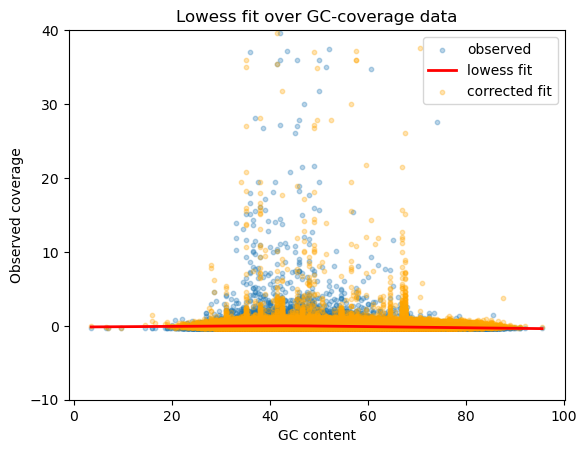

In [60]:
sample = values.iloc[2]
observed_coverage = sample.values
observed_coverage = scale(observed_coverage)
gc_values = gc_content_per_region["gc_content"].values


smoothed = lowess(observed_coverage, 
                  gc_values, 
                  frac=0.75)

# interpolate fitted values back to all regions
fitted = np.interp(gc_values, smoothed[:, 0], smoothed[:, 1])
corrected = observed_coverage - fitted
plt.scatter(gc_values, observed_coverage, alpha=0.3, s=10, label="observed")
plt.plot(smoothed[:, 0], smoothed[:, 1], color="red", linewidth=2, label="lowess fit")
plt.scatter(smoothed[:, 0], corrected, color="orange", alpha=0.3, s=10, label="corrected fit")
plt.xlabel("GC content")
plt.ylabel("Observed coverage")
plt.title("Lowess fit over GC-coverage data")
plt.legend()
plt.ylim(-10, 40)
plt.show()



In [4]:
from modules.matrix_processor import MatrixProcessor
from modules.cfdna_model import CFDNAModel

In [ ]:
mx = coverage_subsample
processor = MatrixProcessor(mx, gc_content_per_region)
model = CFDNAModel(mx, gc_content_per_region, feature="coverage", gc_correction=False)


In [ ]:
res = model.train_svm()
probabilities = res['probabilities']
sample_ids = res['sample_ids']
labels = res['labels']

res_df = pd.DataFrame({
    'probabilities': probabilities,
    'sample_ids': sample_ids,
    'labels': labels
})
res_df.to_csv("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/scripts/modelling/coverage_results.csv", index=False)